# SOK-1305 — Fra inferens til prediksjon

**Multippel regresjon, variabelseleksjon og trening/test på `Boston`**

Vi har til nå brukt regresjon til **inferens**: hvilke variabler henger sammen med
`medv`, og hvor sikre er vi på koeffisientene? Nå snur vi og spør noe annet:
hvor godt treffer modellen på nabolag den **aldri har sett**?

De to spørsmålene har forskjellige svar, og forskjellige verktøy.

| Del | Innhold | Kobling |
|---|---|---|
| 1 | Full modell: $F$-test, $R^2$, justert $R^2$ | kap. 3.2.2 |
| 2 | Baklengs seleksjon | kap. 3.2.2 |
| 3 | Forlengs seleksjon: hele stien | kap. 3.2.2 / 6.1 |
| 4 | Trening og test — hvorfor vi trenger det | kap. 2.2 |
| 5 | **Nøkkelfiguren:** treningsfeil vs. testfeil | kap. 2.2 |
| 6 | Metrikker på begge sett | |
| 7 | Diagnoseplott | kap. 3.3 |
| 8 | En felle: seleksjon før splitting | kap. 5–6 |

Alle 12 prediktorene i `Boston` er med fra start.

## Del 0 — Oppsett

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split

from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize

Boston = load_data("Boston")
ALLE = [k for k in Boston.columns if k != "medv"]

print(f"{Boston.shape[0]} nabolag, {len(ALLE)} prediktorer")
print(ALLE)

506 nabolag, 12 prediktorer
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']


In [3]:
def rmse(faktisk, predikert):
    """Root mean squared error — samme enhet som medv (1000 USD)."""
    faktisk, predikert = np.asarray(faktisk), np.asarray(predikert)
    return float(np.sqrt(np.mean((faktisk - predikert) ** 2)))


def mae(faktisk, predikert):
    """Mean absolute error — mindre følsom for enkeltbom enn RMSE."""
    faktisk, predikert = np.asarray(faktisk), np.asarray(predikert)
    return float(np.mean(np.abs(faktisk - predikert)))


def r2(faktisk, predikert):
    """R^2 regnet ut manuelt, slik at den kan brukes på testsettet også."""
    faktisk, predikert = np.asarray(faktisk), np.asarray(predikert)
    return 1 - ((faktisk - predikert) ** 2).sum() / ((faktisk - faktisk.mean()) ** 2).sum()

## Del 1 — Den fulle modellen

Første steg i enhver multippel regresjon: kjør $F$-testen. Den svarer på ett
spørsmål, og bare ett — er **minst én** av de 12 variablene knyttet til `medv`?

$$H_0:\ \beta_1=\beta_2=\dots=\beta_{12}=0
\qquad\text{mot}\qquad H_a:\ \text{minst én }\beta_j\neq 0$$

In [4]:
y = Boston["medv"]

# Lager en lineær regresjonsmodell med alle prediktorene, og viser oppsummering av resultatene.
full = sm.OLS(y, MS(ALLE).fit_transform(Boston)).fit()

n, p = int(full.nobs), int(full.df_model)
print(f"F = {full.fvalue:.1f}   på ({p}, {n - p - 1}) frihetsgrader")
print(f"p-verdi = {full.f_pvalue:.3e}")
print(f"\nR^2          = {full.rsquared:.4f}")
print(f"justert R^2  = {full.rsquared_adj:.4f}")
print(f"RSE          = {np.sqrt(full.scale):.4f}")

F = 113.5   på (12, 493) frihetsgrader
p-verdi = 2.230e-133

R^2          = 0.7343
justert R^2  = 0.7278
RSE          = 4.7980


$F = 113.5$ mot en kritisk verdi rundt 1,8. Vi forkaster $H_0$ uten videre
diskusjon: **noe** her forklarer `medv`.

Men $F$-testen sier ikke *hva*. Nå ser vi på de individuelle $p$-verdiene, sortert
med de minst overbevisende øverst.

In [5]:
tabell = summarize(full).sort_values("P>|t|", ascending=False)
print(tabell.head(6))
print(f"\nVariabler med p > 0.05: "
      f"{list(tabell[tabell['P>|t|'] > 0.05].index)}")

              coef  std err      t  P>|t|
indus       0.0135    0.062  0.217  0.829
age         0.0036    0.013  0.271  0.787
zn          0.0470    0.014  3.384  0.001
chas        2.8400    0.870  3.264  0.001
tax        -0.0127    0.004 -3.337  0.001
intercept  41.6173    4.936  8.431  0.000

Variabler med p > 0.05: ['indus', 'age']


To kandidater peker seg ut: `indus` ($p = 0.83$) og `age` ($p = 0.79$).

Det er den samme historien som `newspaper` i `Advertising`. Begge er tydelig
korrelerte med `medv` hver for seg — sjekk gjerne selv med en enkel regresjon —
men når resten av modellen er på plass, har de ingenting igjen å bidra med.

In [6]:
for v in ["indus", "age"]:
    enkel = sm.OLS(y, MS([v]).fit_transform(Boston)).fit()
    print(f"{v:>6}: alene p = {enkel.pvalues.iloc[1]:.2e},  "
          f"R^2 = {enkel.rsquared:.3f}   |   "
          f"i full modell p = {full.pvalues[v]:.3f}")

 indus: alene p = 4.90e-31,  R^2 = 0.234   |   i full modell p = 0.829
   age: alene p = 1.57e-18,  R^2 = 0.142   |   i full modell p = 0.787


## Del 2 — Baklengs seleksjon

Algoritmen fra forelesningen: start med alt, fjern variabelen med **størst
$p$-verdi**, tilpass på nytt, gjenta til alle gjenværende ligger under terskelen.

Merk at vi må tilpasse modellen på nytt for hvert steg. $p$-verdiene endrer seg
når naboene forsvinner — det er hele grunnen til at vi ikke bare kan stryke alle
insignifikante variabler på én gang.

In [7]:
def baklengs_seleksjon(data, ynavn, kandidater, terskel=0.05, vis=True):
    """Fjern variabelen med størst p-verdi, én om gangen."""
    igjen = list(kandidater)
    historikk = []

    while len(igjen) > 1:
        res = sm.OLS(data[ynavn], MS(igjen).fit_transform(data)).fit()
        pverdier = res.pvalues.drop("intercept")
        verst, p_maks = pverdier.idxmax(), pverdier.max()

        if p_maks <= terskel:
            break

        historikk.append({"fjernet": verst, "p": p_maks,
                          "antall_for": len(igjen),
                          "R2": res.rsquared, "adj_R2": res.rsquared_adj})
        if vis:
            print(f"  fjerner {verst:<9} p = {p_maks:.4f}    "
                  f"({len(igjen)} -> {len(igjen)-1} variabler)")
        igjen.remove(verst)

    return igjen, pd.DataFrame(historikk)


valgt, historikk = baklengs_seleksjon(Boston, "medv", ALLE)
print(f"\nBeholdt {len(valgt)} variabler:")
print(valgt)

  fjerner indus     p = 0.8285    (12 -> 11 variabler)
  fjerner age       p = 0.7866    (11 -> 10 variabler)

Beholdt 10 variabler:
['crim', 'zn', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio', 'lstat']


In [8]:
redusert = sm.OLS(y, MS(valgt).fit_transform(Boston)).fit()

sml = pd.DataFrame({
    "full (12 var)":     [full.rsquared, full.rsquared_adj,
                          np.sqrt(full.scale), full.aic],
    "redusert (10 var)": [redusert.rsquared, redusert.rsquared_adj,
                          np.sqrt(redusert.scale), redusert.aic]},
    index=["R^2", "justert R^2", "RSE", "AIC"])
print(sml.round(4))

             full (12 var)  redusert (10 var)
R^2                 0.7343             0.7342
justert R^2         0.7278             0.7289
RSE                 4.7980             4.7889
AIC              3035.8207          3031.9441


Her er hele poenget fra forrige forelesning, på ekte data:

* $R^2$ **synker** fra 0,7343 til 0,7342 — men bare i fjerde desimal, og det er
  matematisk garantert at den ikke kan stige når vi fjerner variabler.
* Justert $R^2$ **stiger** fra 0,7278 til 0,7289.
* AIC synker, som også betyr «bedre».

Vi kastet to variabler og fikk en modell som er *bedre* etter alle mål som straffer
kompleksitet. De to variablene kostet frihetsgrader uten å betale for seg.

## Del 3 — Forlengs seleksjon: hele stien

Baklengs ga oss én modell. Nå gjør vi noe mer opplysende: vi kjører **forlengs**
seleksjon helt til alle variablene er inne, og lagrer modellen ved hvert steg.

Da får vi en sti av 12 modeller, én med hvert antall variabler, og kan se hvordan
målene oppfører seg langs den.

In [9]:
def forlengs_sti(data, ynavn, kandidater, maks_steg=None):
    """Legg til variabelen som gir lavest RSS, én om gangen. Returnerer hele stien."""
    inne, ute = [], list(kandidater)
    sti = []
    maks_steg = maks_steg or len(ute)

    for _ in range(maks_steg):
        beste, beste_rss = None, np.inf
        for kandidat in ute:
            res = sm.OLS(data[ynavn],
                         MS(inne + [kandidat]).fit_transform(data)).fit()
            if res.ssr < beste_rss:                 # ssr = RSS
                beste, beste_rss = kandidat, res.ssr
        inne = inne + [beste]
        ute.remove(beste)
        sti.append(list(inne))

    return sti


sti = forlengs_sti(Boston, "medv", ALLE)
for s in sti[:5]:
    print(f"k = {len(s):2d}:  {s}")
print("   ...")

k =  1:  ['lstat']
k =  2:  ['lstat', 'rm']
k =  3:  ['lstat', 'rm', 'ptratio']
k =  4:  ['lstat', 'rm', 'ptratio', 'dis']
k =  5:  ['lstat', 'rm', 'ptratio', 'dis', 'nox']
   ...


In [10]:
rader = []
for s in sti:
    m = sm.OLS(y, MS(s).fit_transform(Boston)).fit()
    rader.append({"k": len(s), "lagt_til": s[-1],
                  "R2": m.rsquared, "justert_R2": m.rsquared_adj,
                  "RSE": np.sqrt(m.scale)})

sti_df = pd.DataFrame(rader)
print(sti_df.to_string(index=False,
                       formatters={"R2": "{:.4f}".format,
                                   "justert_R2": "{:.4f}".format,
                                   "RSE": "{:.4f}".format}))

 k lagt_til     R2 justert_R2    RSE
 1    lstat 0.5441     0.5432 6.2158
 2       rm 0.6386     0.6371 5.5403
 3  ptratio 0.6786     0.6767 5.2294
 4      dis 0.6903     0.6878 5.1386
 5      nox 0.7081     0.7052 4.9939
 6     chas 0.7158     0.7124 4.9326
 7       zn 0.7196     0.7157 4.9040
 8     crim 0.7236     0.7192 4.8738
 9      rad 0.7273     0.7223 4.8466
10      tax 0.7342     0.7289 4.7889
11      age 0.7343     0.7284 4.7934
12    indus 0.7343     0.7278 4.7980


Se på `R2`-kolonnen ovenfra og ned. Den stiger ved **hvert eneste steg**, uten
unntak. Det er ikke flaks — det er garantert, av grunnen vi tegnet opp: den gamle
modellen ligger fortsatt inni den nye som tilfellet der den nye koeffisienten
er null.

Justert $R^2$ oppfører seg annerledes. Den flater ut og snur.

## Del 4 — Hvorfor vi trenger et testsett

Her er problemet vi nå står i. Alle målene i Del 3 er regnet ut på **de samme
dataene som modellen ble tilpasset på**. $R^2$ og RSE svarer på spørsmålet
«hvor godt husker modellen dataene den så?» — ikke «hvor godt gjetter den på nye
nabolag?»

For prediksjon er bare det andre spørsmålet interessant.

Løsningen fra kapittel 2: hold tilbake en del av dataene, la modellen aldri se dem,
og bruk dem til slutt som stand-in for «nye nabolag».

In [12]:
trening, test = train_test_split(Boston, test_size=0.30, random_state=1305)

y_tr, y_te = trening["medv"], test["medv"]

print(f"Trening: {len(trening)} nabolag")
print(f"Test:    {len(test)} nabolag")
print(f"\nmedv gjennomsnitt — trening: {y_tr.mean():.2f},  test: {y_te.mean():.2f}")
print(f"medv std.avvik    — trening: {y_tr.std():.2f},  test: {y_te.std():.2f}")

Trening: 354 nabolag
Test:    152 nabolag

medv gjennomsnitt — trening: 22.75,  test: 22.03
medv std.avvik    — trening: 9.12,  test: 9.39


**`random_state=1305` er viktig.** Uten den får du en ny tilfeldig splitt hver
gang du kjører cella, og alle tall nedenfor endrer seg. Med den er notebooken
reproduserbar — som den må være når dere leverer inn.

Sjekk at gjennomsnitt og standardavvik ligner på hverandre i de to settene. Gjør de
ikke det, har du fått en uheldig splitt, og resultatene blir vanskelige å tolke.

## Del 5 — Nøkkelfiguren

Nå gjør vi et eksperiment som viser hele poenget på én figur.

Vi legger til **12 kolonner med rene tilfeldige tall** i datasettet. De har per
konstruksjon ingenting med boligpriser å gjøre. Så kjører vi forlengs seleksjon
på alle 24 kandidatene — 12 ekte og 12 falske — og måler feilen på begge sett ved
hvert steg.

Tre spørsmål å ha i hodet:

1. Vil noen av støyvariablene bli valgt?
2. Vil treningsfeilen slutte å synke?
3. Vil testfeilen følge treningsfeilen?

In [13]:
rng = np.random.default_rng(1305)

STOY = [f"stoy{i+1}" for i in range(12)]
Boston_stoy = Boston.copy()
for s in STOY:
    Boston_stoy[s] = rng.normal(size=len(Boston))

tr_s = Boston_stoy.loc[trening.index]      # samme splitt som før
te_s = Boston_stoy.loc[test.index]

KANDIDATER = ALLE + STOY
print(f"{len(KANDIDATER)} kandidater: {len(ALLE)} ekte + {len(STOY)} ren støy")

24 kandidater: 12 ekte + 12 ren støy


In [14]:
sti_s = forlengs_sti(tr_s, "medv", KANDIDATER)      # seleksjon KUN på treningssettet

rader = []
for s in sti_s:
    design = MS(s)
    m = sm.OLS(y_tr, design.fit_transform(tr_s)).fit()
    pred_te = m.predict(design.transform(te_s))
    rader.append({
        "k": len(s),
        "lagt_til": s[-1],
        "R2_tren": m.rsquared,
        "justert_R2": m.rsquared_adj,
        "RMSE_tren": rmse(y_tr, m.fittedvalues),
        "RMSE_test": rmse(y_te, pred_te),
        "R2_test": r2(y_te, pred_te)})

res_sti = pd.DataFrame(rader)
print(res_sti.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

 k lagt_til  R2_tren  justert_R2  RMSE_tren  RMSE_test  R2_test
 1    lstat   0.5450      0.5437     6.1430     6.3770   0.5354
 2       rm   0.6130      0.6108     5.6650     5.3014   0.6789
 3  ptratio   0.6443      0.6413     5.4308     4.7812   0.7388
 4     chas   0.6610      0.6571     5.3023     4.8809   0.7278
 5      dis   0.6732      0.6685     5.2060     4.8490   0.7314
 6      nox   0.6848      0.6793     5.1129     4.5212   0.7665
 7       zn   0.6900      0.6838     5.0700     4.5107   0.7676
 8    stoy2   0.6945      0.6874     5.0333     4.5426   0.7643
 9     crim   0.6978      0.6899     5.0063     4.5080   0.7678
10      rad   0.7031      0.6944     4.9621     4.4931   0.7694
11      tax   0.7119      0.7027     4.8875     4.4691   0.7718
12    stoy9   0.7143      0.7042     4.8675     4.4976   0.7689
13    stoy6   0.7160      0.7051     4.8532     4.5662   0.7618
14   stoy10   0.7172      0.7056     4.8423     4.5871   0.7596
15      age   0.7185      0.7060     4.8

In [15]:
k_best_test = int(res_sti.loc[res_sti["RMSE_test"].idxmin(), "k"])
k_best_adj = int(res_sti.loc[res_sti["justert_R2"].idxmax(), "k"])
stoy_valgt = [v for v in sti_s[11] if v.startswith("stoy")]

print(f"Lavest test-RMSE ved  k = {k_best_test}")
print(f"Høyest justert R^2 ved k = {k_best_adj}")
print(f"\nStøyvariabler blant de 12 først valgte: {stoy_valgt}")
print(f"\nR^2 på trening, første til siste steg: "
      f"{res_sti['R2_tren'].iloc[0]:.4f} -> {res_sti['R2_tren'].iloc[-1]:.4f}")
print(f"Sank R^2 noen gang underveis? "
      f"{(res_sti['R2_tren'].diff().dropna() < 0).any()}")

Lavest test-RMSE ved  k = 11
Høyest justert R^2 ved k = 15

Støyvariabler blant de 12 først valgte: ['stoy2', 'stoy9']

R^2 på trening, første til siste steg: 0.5450 -> 0.7211
Sank R^2 noen gang underveis? False


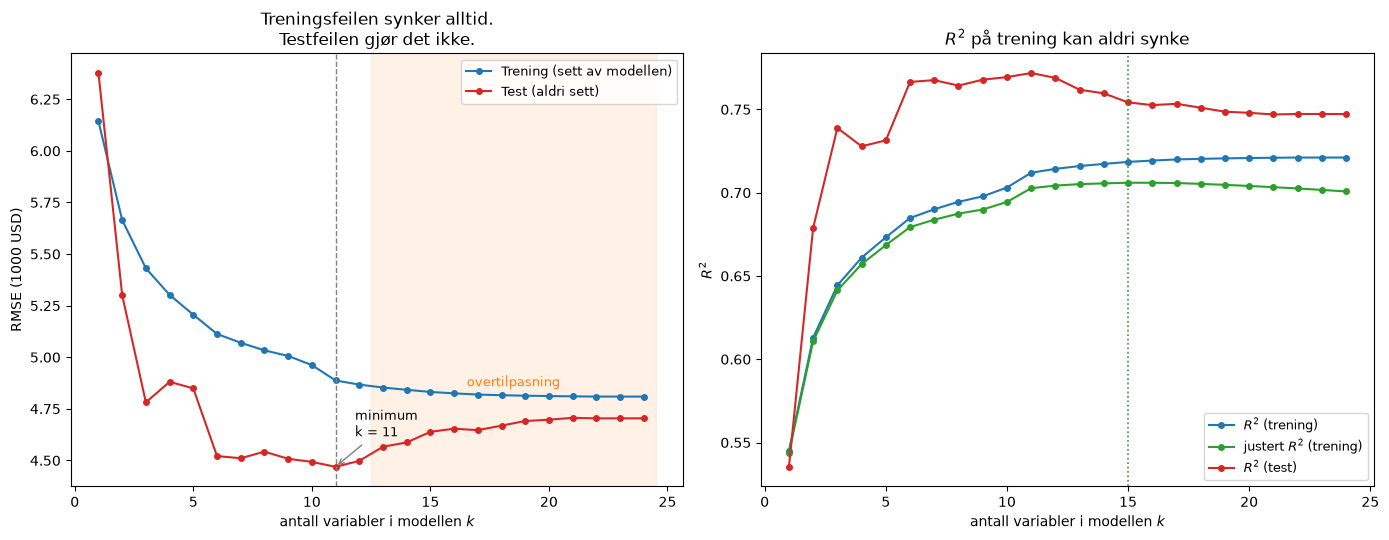

In [16]:
fig, (a1, a2) = subplots(1, 2, figsize=(14, 5.5))
k = res_sti["k"]

# --- venstre: treningsfeil vs testfeil ---
a1.plot(k, res_sti["RMSE_tren"], "o-", color="tab:blue", ms=4,
        label="Trening (sett av modellen)")
a1.plot(k, res_sti["RMSE_test"], "o-", color="tab:red", ms=4,
        label="Test (aldri sett)")
a1.axvline(k_best_test, color="grey", ls="--", lw=1)
a1.annotate(f"minimum\nk = {k_best_test}",
            (k_best_test, res_sti["RMSE_test"].min()),
            textcoords="offset points", xytext=(14, 22), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey"))
a1.axvspan(12.5, 24.5, color="tab:orange", alpha=.10)
a1.text(18.5, res_sti["RMSE_tren"].min() + .05, "overtilpasning",
        ha="center", fontsize=9, color="tab:orange")
a1.set_xlabel("antall variabler i modellen $k$")
a1.set_ylabel("RMSE (1000 USD)")
a1.set_title("Treningsfeilen synker alltid.\nTestfeilen gjør det ikke.")
a1.legend(fontsize=9)

# --- høyre: R^2 vs justert R^2 ---
a2.plot(k, res_sti["R2_tren"], "o-", color="tab:blue", ms=4, label="$R^2$ (trening)")
a2.plot(k, res_sti["justert_R2"], "o-", color="tab:green", ms=4,
        label="justert $R^2$ (trening)")
a2.plot(k, res_sti["R2_test"], "o-", color="tab:red", ms=4, label="$R^2$ (test)")
a2.axvline(k_best_adj, color="tab:green", ls=":", lw=1.2)
a2.set_xlabel("antall variabler i modellen $k$")
a2.set_ylabel("$R^2$")
a2.set_title("$R^2$ på trening kan aldri synke")
a2.legend(fontsize=9, loc="lower right")

plt.tight_layout()

### Hva figuren viser

**Blå kurve, venstre panel: treningsfeilen synker monotont.** Fra første til siste
variabel, uten unntak — også når variabelen som legges til er et tilfeldig tall.
Modellen blir aldri dårligere til å huske data den allerede har sett.

**Rød kurve: testfeilen har en bunn og snur.** Etter et visst punkt gjør hver ny
variabel modellen *verre* på nabolag den ikke har sett. Den lærer seg tilfeldigheter
i treningssettet som ikke gjentar seg andre steder. Det er **overtilpasning**, og
den er usynlig hvis du bare ser på treningsdataene.

**Støyvariabler blir valgt.** Se hvilke variabler som havner blant de 12 først
valgte. Algoritmen har ingen måte å vite at de er falske — de reduserer RSS på
treningssettet, akkurat som ekte variabler gjør, bare litt mindre.

**Høyre panel:** blå $R^2$ klatrer i en jevn, ubrutt linje. Grønn justert $R^2$
flater ut og snur, fordi den betaler en straff per variabel. Rød test-$R^2$ er den
eneste som svarer på spørsmålet vi faktisk bryr oss om.

## Del 6 — Metrikker for tre modeller

Nå sammenligner vi tre konkrete modeller på begge sett:

* **Enkel:** bare `lstat`
* **Valgt:** de 10 variablene fra baklengs seleksjon i Del 2
* **Full:** alle 12

Tre mål, som svarer på litt forskjellige spørsmål:

| Mål | Enhet | Egenskap |
|---|---|---|
| RMSE | 1000 USD | straffer store bom hardt (kvadrering) |
| MAE | 1000 USD | behandler alle bom likt |
| $R^2$ | enhetsløs | andel forklart variasjon |

In [17]:
modeller = {"Enkel (lstat)": ["lstat"],
            f"Valgt ({len(valgt)} var)": valgt,
            f"Full ({len(ALLE)} var)": ALLE}

rader = []
for navn, terms in modeller.items():
    design = MS(terms)
    m = sm.OLS(y_tr, design.fit_transform(trening)).fit()
    p_tr = m.fittedvalues
    p_te = m.predict(design.transform(test))
    rader.append({
        "modell": navn, "k": len(terms),
        "RMSE_tren": rmse(y_tr, p_tr), "RMSE_test": rmse(y_te, p_te),
        "MAE_tren": mae(y_tr, p_tr),   "MAE_test": mae(y_te, p_te),
        "R2_tren": r2(y_tr, p_tr),     "R2_test": r2(y_te, p_te)})

metrikker = pd.DataFrame(rader).set_index("modell")
print(metrikker.round(4).to_string())

print("\nGap mellom trening og test (RMSE_test - RMSE_tren):")
for navn, r in metrikker.iterrows():
    print(f"   {navn:<18} {r['RMSE_test'] - r['RMSE_tren']:+.4f}")

                 k  RMSE_tren  RMSE_test  MAE_tren  MAE_test  R2_tren  R2_test
modell                                                                        
Enkel (lstat)    1     6.1430     6.3770    4.5129    4.6303   0.5450   0.5354
Valgt (10 var)  10     4.9148     4.4446    3.4890    3.2394   0.7087   0.7743
Full (12 var)   12     4.9049     4.4936    3.4871    3.2442   0.7099   0.7693

Gap mellom trening og test (RMSE_test - RMSE_tren):
   Enkel (lstat)      +0.2341
   Valgt (10 var)     -0.4702
   Full (12 var)      -0.4114


**Hvordan lese tabellen.** Er `RMSE_test` mye større enn `RMSE_tren`, har
modellen tilpasset seg treningssettet. Er de like, generaliserer den godt.

Merk at RMSE er større enn MAE i alle rader. Det er alltid tilfelle, og forskjellen
forteller hvor skjevfordelt feilene er: er noen få nabolag katastrofalt bomma på,
sprer RMSE og MAE seg fra hverandre.

**Er testfeilen lavere enn treningsfeilen?** Det skjer, og det er ikke en feil.
Med denne splitten er `RMSE_test` faktisk *lavere* enn `RMSE_tren` for de to store
modellene. Testsettet på 152 nabolag ble tilfeldigvis litt lettere enn de 354
treningsnabolagene. Det er nettopp derfor oppgave 1 ber dere kjøre om igjen med
andre `random_state` --- ett enkelt tall fra én enkelt splitt er støyete.

**En advarsel om test-$R^2$.** I motsetning til på treningssettet kan test-$R^2$
bli **negativ**. Det betyr at modellen gjetter dårligere enn å bare bruke
gjennomsnittet av treningssettet hver gang. Skjer det, er noe alvorlig galt.

## Del 7 — Diagnoseplott

Tall i en tabell skjuler mønstre. To figurer avslører dem.

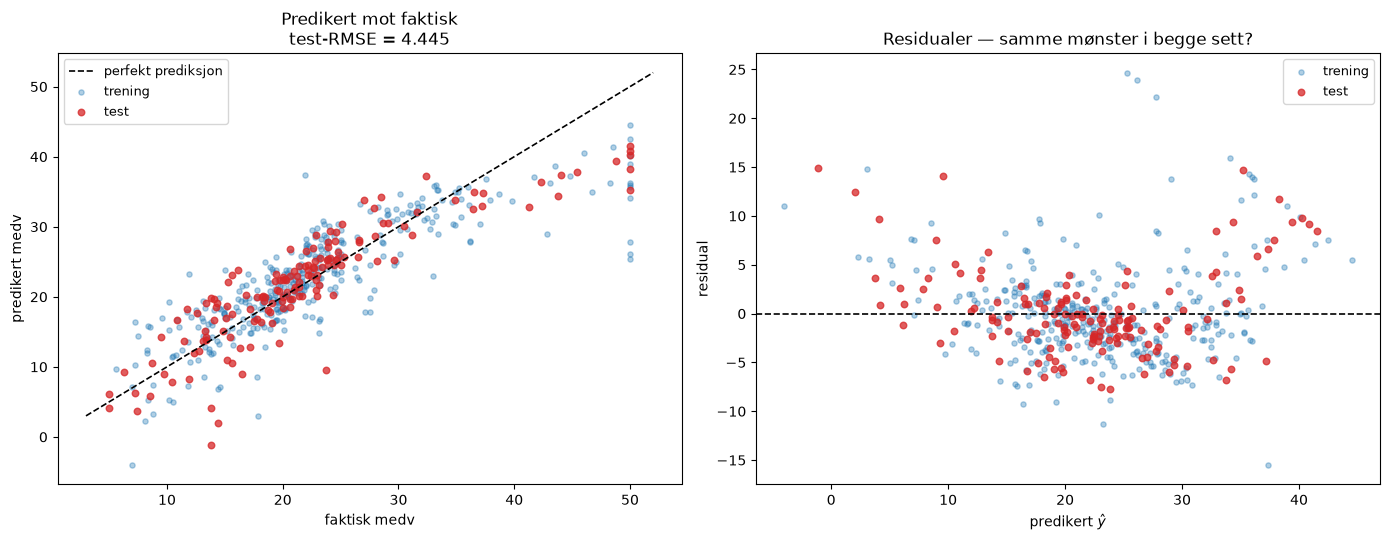

In [18]:
design_v = MS(valgt)
m_v = sm.OLS(y_tr, design_v.fit_transform(trening)).fit()
pred_tr = m_v.fittedvalues
pred_te = m_v.predict(design_v.transform(test))

fig, (a1, a2) = subplots(1, 2, figsize=(14, 5.5))

# --- predikert mot faktisk ---
grense = [min(y_tr.min(), y_te.min()) - 2, max(y_tr.max(), y_te.max()) + 2]
a1.plot(grense, grense, "k--", lw=1.2, label="perfekt prediksjon")
a1.scatter(y_tr, pred_tr, s=14, alpha=.35, color="tab:blue", label="trening")
a1.scatter(y_te, pred_te, s=22, alpha=.75, color="tab:red", label="test")
a1.set_xlabel("faktisk medv"); a1.set_ylabel("predikert medv")
a1.set_title(f"Predikert mot faktisk\ntest-RMSE = {rmse(y_te, pred_te):.3f}")
a1.legend(fontsize=9)

# --- residualer ---
a2.scatter(pred_tr, y_tr - pred_tr, s=14, alpha=.35, color="tab:blue",
           label="trening")
a2.scatter(pred_te, y_te - pred_te, s=22, alpha=.75, color="tab:red",
           label="test")
a2.axhline(0, color="k", ls="--", lw=1.2)
a2.set_xlabel(r"predikert $\hat{y}$"); a2.set_ylabel("residual")
a2.set_title("Residualer — samme mønster i begge sett?")
a2.legend(fontsize=9)

plt.tight_layout()

**Venstre:** ligger punktene tett rundt diagonalen, treffer modellen godt. Legg
merke til klyngen ved `medv` = 50 — det er sensurerte verdier i datasettet
(alt over 50 er registrert som 50), og modellen kan umulig treffe dem.

**Høyre:** samme U-form som i enkel regresjon. Modellen underpredikerer i begge
ender. At de røde testpunktene følger nøyaktig samme mønster er faktisk godt nytt
metodisk — problemet er systematisk og skyldes modellformen, ikke en uheldig splitt.

At vi har brukt 10 variabler i stedet for 1 har ikke fjernet krumningen. Det er
et **spesifikasjonsproblem**, ikke et variabeltellingsproblem, og løses med
transformasjoner eller ikke-lineære metoder.

## Del 8 — En felle: seleksjon før splitting

Til slutt en metodisk detalj som er lett å trå feil på.

I Del 2 kjørte vi baklengs seleksjon på **hele** datasettet og splittet først
etterpå. Det virker uskyldig. Men da har testsettet vært med på å bestemme hvilke
variabler modellen får bruke --- og da er det ikke lenger «aldri sett».

For å måle effekten trenger vi et oppsett der det er noe å ta feil av: 80
støyvariabler, og forlengs seleksjon som tvinges til å velge 20 av dem uten
noen $p$-verdi-terskel som kan stoppe den.

In [19]:
rng2 = np.random.default_rng(1305)

MANGE_STOY = [f"s{i}" for i in range(80)]
Boston_80 = Boston.copy()
for kol in MANGE_STOY:
    Boston_80[kol] = rng2.normal(size=len(Boston))

KAND_80 = ALLE + MANGE_STOY
tr80 = Boston_80.loc[trening.index]
te80 = Boston_80.loc[test.index]

K = 20


def test_rmse_for(variabler):
    design = MS(variabler)
    m = sm.OLS(y_tr, design.fit_transform(tr80)).fit()
    return rmse(y_te, m.predict(design.transform(te80)))


def antall_stoy(variabler):
    return sum(1 for v in variabler if v in MANGE_STOY)


# (a) FEIL: seleksjon på alt, deretter splitting
valgt_a = forlengs_sti(Boston_80, "medv", KAND_80, maks_steg=K)[-1]

# (b) RIKTIG: splitt først, seleksjon kun på treningssettet
valgt_b = forlengs_sti(tr80, "medv", KAND_80, maks_steg=K)[-1]

print(f"(a) seleksjon på ALT      test-RMSE = {test_rmse_for(valgt_a):.4f}   "
      f"({antall_stoy(valgt_a)} av {K} er støy)")
print(f"(b) seleksjon på TRENING  test-RMSE = {test_rmse_for(valgt_b):.4f}   "
      f"({antall_stoy(valgt_b)} av {K} er støy)")
print(f"\n(a) ser {test_rmse_for(valgt_b) - test_rmse_for(valgt_a):.4f} bedre ut "
      f"— men tallet er ikke til å stole på.")

(a) seleksjon på ALT      test-RMSE = 4.4770   (10 av 20 er støy)
(b) seleksjon på TRENING  test-RMSE = 5.0463   (9 av 20 er støy)

(a) ser 0.5693 bedre ut — men tallet er ikke til å stole på.


Legg merke til retningen: den **feilaktige** framgangsmåten gir det
**penere** tallet. Det er slik denne feilen overlever --- den blir aldri oppdaget,
fordi resultatet ser bra ut.

Forklaringen er at når vi velger støyvariabler ved å se på alle 506 nabolagene,
plukker vi ut nettopp de som tilfeldigvis korrelerer med `medv` *også i de 152
testnabolagene*. Testsettet har dermed hjulpet oss med å jukse, og test-RMSE måler
ikke lenger generalisering til nye data.

Gjør vi det riktig, får vi et dårligere, men ærlig tall.

Regelen: **alt som ser på responsen $y$ må skje etter splittingen.**
Variabelseleksjon, valg av transformasjoner, valg av terskler --- alt sammen.
Dette er utgangspunktet for kryssvalidering i kapittel 5, som løser problemet
mer elegant enn en enkelt splitt.